# **Data Science Advanced Assessment : Weather Trend Forecasting**

##**JJ Gougassian**

The goal of this project is to forecast future weather trends using data science techniques. We will be using the "Global Weather Repository.csv" dataset for this assessment. We will perform data cleaning & preprocessing, advanced exploratory analysis to find unique patterns and train multiple models in order to find which ones perform best.

This project aligns with PM Accelerator’s mission of making tools and knowledge accessible by using data science to analyze real-world data and generate insights. It demonstrates how machine learning and data-driven approaches can help individuals better understand problems and make informed decisions, reflecting the company’s focus on education, accessibility, and innovation.

Importing libraries we might need :

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##**Preprocessing**

Initializing our dataset

In [ ]:
!pip install -q gdown

import gdown

file_id= "1AQ9pk8kR3PlSN4jttepVr-nlM5xlkN-X"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "GlobalWeatherRepository.csv", quiet=False)


weather_df = pd.read_csv('GlobalWeatherRepository.csv')

Downloading...
From: https://drive.google.com/uc?id=1AQ9pk8kR3PlSN4jttepVr-nlM5xlkN-X
To: /content/GlobalWeatherRepository.csv
100%|██████████| 33.0M/33.0M [00:00<00:00, 70.0MB/s]


First look at our dataset :

In [ ]:
weather_df.head().T

,0,1,2,3,4
country,Afghanistan,Albania,Algeria,Andorra,Angola
location_name,Kabul,Tirana,Algiers,Andorra La Vella,Luanda
latitude,34.52,41.33,36.76,42.50,-8.84
longitude,69.18,19.82,3.05,1.52,13.23
timezone,Asia/Kabul,Europe/Tirane,Africa/Algiers,Europe/Andorra,Africa/Luanda
last_updated_epoch,1715849100,1715849100,1715849100,1715849100,1715849100
last_updated,2024-05-16 13:15,2024-05-16 10:45,2024-05-16 09:45,2024-05-16 10:45,2024-05-16 09:45
temperature_celsius,26.60,19.00,23.00,6.30,26.00
temperature_fahrenheit,79.80,66.20,73.40,43.30,78.80
condition_text,Partly Cloudy,Partly cloudy,Sunny,Light drizzle,Partly cloudy


Upon first inspection of the dataset, our target variable will be `temperature_celsius`. This is the value we will want the ML models to predict, and most of the columns can serve as important feature variables.

In [ ]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124916 entries, 0 to 124915
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       124916 non-null  object 
 1   location_name                 124916 non-null  object 
 2   latitude                      124916 non-null  float64
 3   longitude                     124916 non-null  float64
 4   timezone                      124916 non-null  object 
 5   last_updated_epoch            124916 non-null  int64  
 6   last_updated                  124916 non-null  object 
 7   temperature_celsius           124916 non-null  float64
 8   temperature_fahrenheit        124916 non-null  float64
 9   condition_text                124916 non-null  object 
 10  wind_mph                      124916 non-null  float64
 11  wind_kph                      124916 non-null  float64
 12  wind_degree                   124916 non-nul

Our dataset contains 124,916 rows with 41 total columns. Most of the columns are already numerical, but some are not like `condition_text` or `wind_direction`. These columns will need to be transformed to numbers in order for our ML models to process them later. But first, we need to check if we must fill any null values :

In [ ]:
weather_df.isnull().sum()

,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


Surprisingly enough, there are no null values to fill in the whole dataset. That saves us some time! Now we will start to transform our data into numbers. We will begin by converting `last_updated` into datetime format :

In [ ]:
weather_df['last_updated'] = pd.to_datetime(weather_df['last_updated'])

In [ ]:
weather_df['last_updated']

,last_updated
0,2024-05-16 13:15:00
1,2024-05-16 10:45:00
2,2024-05-16 09:45:00
3,2024-05-16 10:45:00
4,2024-05-16 09:45:00
...,...
124911,2026-02-18 02:45:00
124912,2026-02-18 13:45:00
124913,2026-02-18 09:45:00
124914,2026-02-18 08:45:00


Our `last_updated` column is now of datetime type. This feature is crucial as it's the feature that tells us the exact time the weather got recorded. Now we want to enrich the time & date component as much as possible. Let's start by making sure the dataframe is sorted by date order.

In [ ]:
weather_df.sort_values(by=['last_updated'], inplace=True, ascending=True)

In [ ]:
weather_df.head(20)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
186,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,Clear,...,6.3,7.1,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55
52,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,Moderate or heavy rain with thunder,...,20.4,28.1,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55
40,Costa Rica,San Juan,9.97,-84.08,America/Costa_Rica,1715849100,2024-05-16 02:45:00,21.0,69.8,Fog,...,21.7,23.3,2,2,05:15 AM,05:51 PM,12:42 PM,12:37 AM,Waxing Gibbous,55
68,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,Mist,...,132.0,178.1,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55
124,Nicaragua,Managua,12.15,-86.27,America/Managua,1715849100,2024-05-16 02:45:00,27.2,80.9,Patchy rain nearby,...,11.7,14.7,1,1,05:21 AM,06:02 PM,12:49 PM,12:49 AM,Waxing Gibbous,55
17,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,Overcast,...,7.7,32.1,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55
74,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,Partly cloudy,...,19.0,25.3,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55
110,Mexico,Mexico City,19.43,-99.13,America/Mexico_City,1715849100,2024-05-16 02:45:00,20.8,69.4,Clear,...,35.1,48.0,2,3,06:01 AM,07:05 PM,01:37 PM,01:49 AM,Waxing Gibbous,55
50,Ecuador,Quito,-0.22,-78.50,America/Guayaquil,1715849100,2024-05-16 03:45:00,11.9,53.3,Patchy rain nearby,...,26.3,28.9,2,3,06:07 AM,06:13 PM,01:27 PM,01:05 AM,Waxing Gibbous,55
137,Peru,Lima,-12.05,-77.05,America/Lima,1715849100,2024-05-16 03:45:00,16.6,61.9,Partly Cloudy,...,9.6,20.2,1,1,06:18 AM,05:51 PM,01:30 PM,12:47 AM,Waxing Gibbous,55


Now we can add extra numerical columns for more specific date info. Weather changes by year, month and hour so we will record these for our analysis :

In [ ]:
weather_df["Year"] = weather_df.last_updated.dt.year
weather_df["Month"] = weather_df.last_updated.dt.month
weather_df["DayOfYear"] = weather_df.last_updated.dt.dayofyear
weather_df["Hour"] = weather_df.last_updated.dt.hour
weather_df["Minute"] = weather_df.last_updated.dt.minute

In [ ]:
weather_df.head().T

,186,52,40,68,124
country,United States of America,El Salvador,Costa Rica,Guatemala,Nicaragua
location_name,Washington Park,San Salvador,San Juan,Guatemala City,Managua
latitude,46.6,13.71,9.97,14.62,12.15
longitude,-120.49,-89.2,-84.08,-90.53,-86.27
timezone,America/Los_Angeles,America/El_Salvador,America/Costa_Rica,America/Guatemala,America/Managua
last_updated_epoch,1715849100,1715849100,1715849100,1715849100,1715849100
last_updated,2024-05-16 01:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00
temperature_celsius,16.1,26.0,21.0,20.0,27.2
temperature_fahrenheit,61.0,78.8,69.8,68.0,80.9
condition_text,Clear,Moderate or heavy rain with thunder,Fog,Mist,Patchy rain nearby


We have now enriched date and time details into multiple numerical columns. <br>
<br> While these columns allow us to better visualize insights in graphs and plots, ML models do not know that the 11pm hour (represented by number 23 in our dataset) is close to the midnight hour (represented by 0), or that December (12) is close to January (1). It will judge them as far apart since their numbers represent a big distance, but in reality time and weather are periodic. So in order to improve our data for model training, we need to find a way to represent the time and months periodically using cyclical encoding. We can use sin and cos to achieve that.


These separation would allow us to analyze distribution more cleanly later in analysis, and would also allow ML models to read date and time in an efficient manner.

In [ ]:
weather_df['Month_sin'] = np.sin(2* np.pi * weather_df['Month'] / 12)
weather_df['Month_cos'] = np.cos(2* np.pi * weather_df['Month'] / 12)

weather_df['Hour_sin'] = np.sin(2* np.pi * weather_df['Hour'] / 24)
weather_df['Hour_cos'] = np.cos(2* np.pi * weather_df['Hour'] / 24)

weather_df['DayOfYear_sin'] = np.sin(2* np.pi * weather_df['DayOfYear'] / 365)
weather_df['DayOfYear_cos'] = np.cos(2* np.pi * weather_df['DayOfYear'] / 365)

weather_df['Minute_sin'] = np.sin(2* np.pi * weather_df['Minute'] / 60)
weather_df['Minute_cos'] = np.cos(2* np.pi * weather_df['Minute'] / 60)

Simple example to picture the improvement :

In [ ]:
# Geometrical distance between Hour '23' and Hour '0'
distance_hour = 23 - 0

In [ ]:
distance_hour

23

In [ ]:
hour23_cos = np.cos(2* np.pi * 23 / 24)
hour23_sin = np.sin(2* np.pi * 23 / 24)

hour0_cos = np.cos(0)
hour0_sin = np.sin(0)

In [ ]:
(hour23_cos, hour23_sin), (hour0_cos, hour0_sin)

((np.float64(0.9659258262890681), np.float64(-0.25881904510252157)),
 (np.float64(1.0), np.float64(0.0)))

Now both hours are converted into 2d points to capture periodicity

In [ ]:
# Geometrical distance between the 2d points
distance = np.sqrt(np.square(hour23_cos - hour0_cos) + np.square(hour23_sin - hour0_sin))

In [ ]:
distance

np.float64(0.261052384440104)

The geometrical distance is now only 0.26, which is small. This insight will be crucial for our ML models. <br><br> Now, we will turn the other categorical columns into numbers.

In [ ]:
weather_df.head().T

,186,52,40,68,124
country,United States of America,El Salvador,Costa Rica,Guatemala,Nicaragua
location_name,Washington Park,San Salvador,San Juan,Guatemala City,Managua
latitude,46.6,13.71,9.97,14.62,12.15
longitude,-120.49,-89.2,-84.08,-90.53,-86.27
timezone,America/Los_Angeles,America/El_Salvador,America/Costa_Rica,America/Guatemala,America/Managua
last_updated_epoch,1715849100,1715849100,1715849100,1715849100,1715849100
last_updated,2024-05-16 01:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00
temperature_celsius,16.1,26.0,21.0,20.0,27.2
temperature_fahrenheit,61.0,78.8,69.8,68.0,80.9
condition_text,Clear,Moderate or heavy rain with thunder,Fog,Mist,Patchy rain nearby


In [ ]:
weather_df['location_name'].nunique(), weather_df['country'].nunique()

(256, 211)

It would be challenging to compare by region based on `location_name` or `country` because a lot of different cities and countries are recorded. And organizing them into a more concise `continent` column would be tedious manulaly. And there's also no need to encode `location_name`, `timezone` and `country` into numerical columns. This will result in too many redundant features that can increase overfitting. Instead, we are gonna rely on the `latitude` column. The latitude represents the distance between each region to the equator which is crucial for determining weather. We will enrich it into 3 different categories (near equator, mid latitude and high latitude) for our data visualization later on. But for ML models we will feed it the raw `latitude` feature only to keep it precise.

In [ ]:
weather_df['latitude'].max(), weather_df['latitude'].min()

(64.15, -41.3)

In [ ]:
weather_df['lat_zone'] = pd.cut(
    np.abs(weather_df['latitude']),
    bins=[0, 15, 35, np.inf],
    labels=['Near Equator', 'Mid Latitude', 'High Latitude']
)

Brilliant. We have now enriched `latitude` into 3 categories. First category is near equator for latitudes with an absolute value bwtween 0 and 15, mid latitude for the ones with an abs value between 15 and 35, and then high latitude for the ones between 35 and 64. <br> Moreover in our data preprocessing, we can also enrich `sunrise` and `sunset` into a new `daytime_duration_mins` column, which will record the total day light time in mins for each given day.

In [ ]:
weather_df['sunrise'] = pd.to_datetime(weather_df['sunrise'])
weather_df['sunset'] = pd.to_datetime(weather_df['sunset'])

/tmp/ipython-input-353/2715075793.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_df['sunrise'] = pd.to_datetime(weather_df['sunrise'])
/tmp/ipython-input-353/2715075793.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weather_df['sunset'] = pd.to_datetime(weather_df['sunset'])


In [ ]:
sunrise_hour = weather_df['sunrise'].dt.hour
sunrise_minute = weather_df['sunrise'].dt.minute

sunset_hour = weather_df['sunset'].dt.hour
sunset_minute = weather_df['sunset'].dt.minute

sunrise_time_mins = sunrise_hour * 60 + sunrise_minute
sunset_time_mins = sunset_hour * 60 + sunset_minute

In [ ]:
weather_df['daytime_duration_mins'] = sunset_time_mins - sunrise_time_mins

Now, let's look for other features that might need preprocessing :

In [ ]:
weather_df['condition_text'].unique()

array(['Clear', 'Moderate or heavy rain with thunder', 'Fog', 'Mist',
       'Patchy rain nearby', 'Overcast', 'Partly cloudy', 'Partly Cloudy',
       'Sunny', 'Moderate or heavy rain shower', 'Light rain',
       'Moderate rain', 'Light drizzle', 'Thundery outbreaks in nearby',
       'Patchy light rain in area with thunder',
       'Patchy light rain with thunder', 'Moderate rain at times',
       'Light rain shower', 'Cloudy', 'Heavy rain at times',
       'Patchy light rain', 'Patchy light drizzle',
       'Thundery outbreaks possible', 'Patchy rain possible',
       'Moderate or heavy rain in area with thunder', 'Heavy rain',
       'Torrential rain shower', 'Freezing fog',
       'Moderate or heavy snow showers', 'Light sleet', 'Blizzard',
       'Moderate snow', 'Light snow', 'Light sleet showers',
       'Light freezing rain', 'Heavy snow', 'Blowing snow',
       'Patchy heavy snow', 'Light snow showers',
       'Moderate or heavy sleet', 'Patchy light snow',
       'Patchy mo

This feature has a high variability in text and a lot of overlap between different condition types. Not only would it be cumbersome to organize them into smaller, more concise categories, I also assume this attribute would also give the models a summary of the weather itself, which might not be helpful. So I will decide to not make use of it for this exercise. `moon_phase` is also irrelevant to predict weather so we will drop it. <br> Now, we will inspect the `wind_direction` attribute. Wind direction is crucial to estimate temperature :

In [ ]:
weather_df['wind_direction'].unique()

array(['SW', 'S', 'N', 'ESE', 'E', 'WSW', 'SSW', 'SE', 'SSE', 'ENE', 'NE',
       'NNE', 'NNW', 'WNW', 'W', 'NW'], dtype=object)

The true cardinal direction starting from the north is :<br> <br><b>N, NNE, NE, ENE, E, ESE, SE, S, SSW, SW, WSW, W ,WW, NW, NNW  </b>with degree angles :<br> <b>0, 22.5, 45, 67.5, 90, 112.5, 135, 157,5, 180, 202.5, 225, 247.5, 270, 292.5, 315, 337.5 </b>respectively.<br><br> Since angles are periodic (angle 0 = angle 360), we will encode them using 2 new cos and sin features, which map each angle to a pont on a circle.

In [ ]:
direction_to_angle = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

wind_angle = weather_df['wind_direction'].map(direction_to_angle)
wind_angle_rad = np.deg2rad(wind_angle)
weather_df['wind_direction_sin'] = np.sin(wind_angle_rad)
weather_df['wind_direction_cos'] = np.cos(wind_angle_rad)


In [ ]:
weather_df.head().T

,186,52,40,68,124
country,United States of America,El Salvador,Costa Rica,Guatemala,Nicaragua
location_name,Washington Park,San Salvador,San Juan,Guatemala City,Managua
latitude,46.6,13.71,9.97,14.62,12.15
longitude,-120.49,-89.2,-84.08,-90.53,-86.27
timezone,America/Los_Angeles,America/El_Salvador,America/Costa_Rica,America/Guatemala,America/Managua
last_updated_epoch,1715849100,1715849100,1715849100,1715849100,1715849100
last_updated,2024-05-16 01:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00
temperature_celsius,16.1,26.0,21.0,20.0,27.2
temperature_fahrenheit,61.0,78.8,69.8,68.0,80.9
condition_text,Clear,Moderate or heavy rain with thunder,Fog,Mist,Patchy rain nearby


We can now drop the features that are no longer needed :

In [ ]:
columns = ['moon_phase', 'condition_text']
weather_df.drop(columns=columns, inplace=True)

Since we need to implement anomaly detection, we will not be removing outliers. We can now start the data visualization section.

##**Exploratory Data Analysis**

### Temperature variations by time :

/tmp/ipython-input-353/2957073918.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_temp.index, y=mean_temp.values, palette='Set1', ax= axes[1])
/tmp/ipython-input-353/2957073918.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)


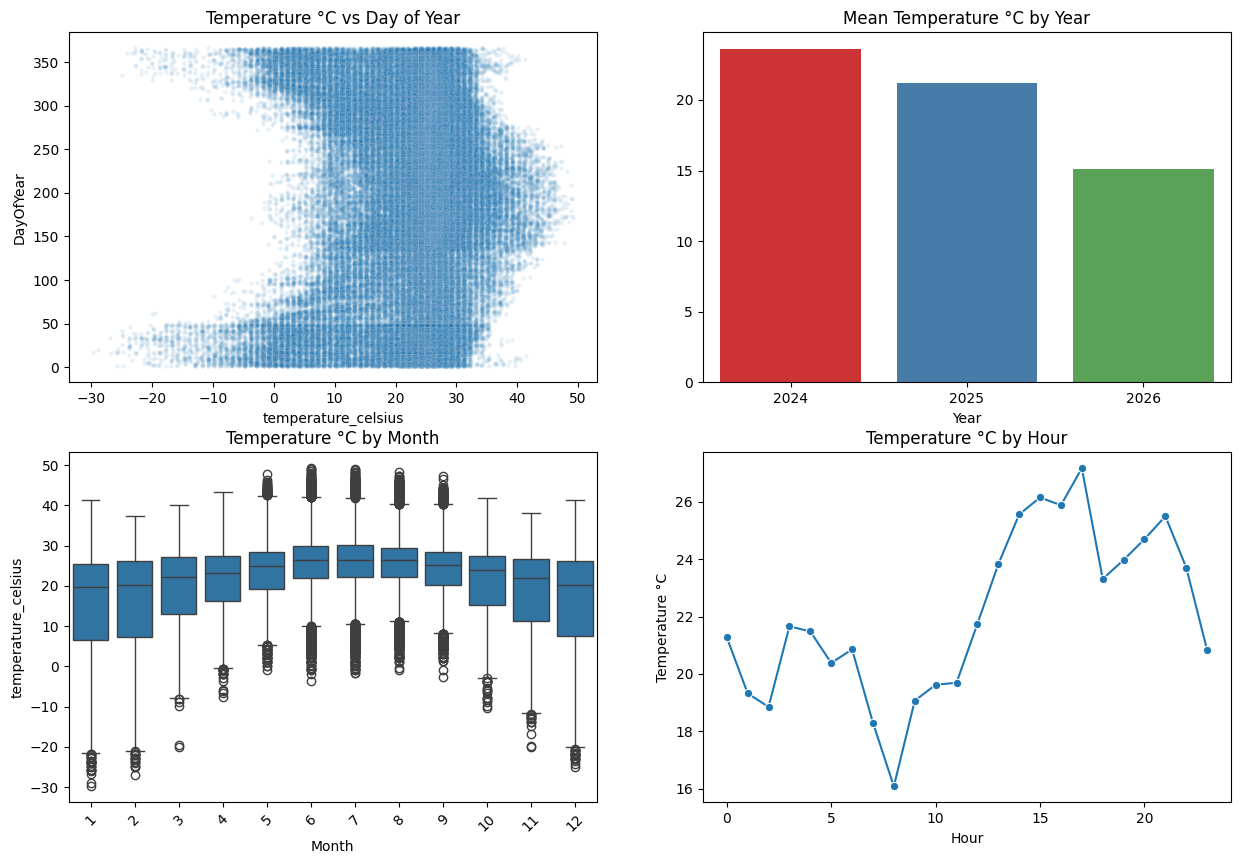

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(15,10))
axes = axes.flatten()

sns.scatterplot(x='temperature_celsius', y='DayOfYear', data=weather_df,alpha=0.1,s=10, ax= axes[0])

mean_temp = weather_df.groupby('Year')['temperature_celsius'].mean()

sns.barplot(x=mean_temp.index, y=mean_temp.values, palette='Set1', ax= axes[1])

sns.boxplot(
    x='Month',
    y='temperature_celsius',
     data=weather_df,
    ax= axes[2]
)
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)


hourly_avg = weather_df.groupby('Hour')['temperature_celsius'].mean()

sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o', ax= axes[3])
axes[3].set_ylabel("Temperature °C")

axes[0].set_title("Temperature °C vs Day of Year")
axes[1].set_title("Mean Temperature °C by Year")
axes[2].set_title("Temperature °C by Month")
axes[3].set_title("Temperature °C by Hour")
plt.show();




In [ ]:
year_means = weather_df.groupby('Year')['temperature_celsius'].mean()
year_medians = weather_df.groupby('Year')['temperature_celsius'].median()
month_medians = weather_df.groupby('Month')['temperature_celsius'].median()
hour_means = weather_df.groupby('Hour')['temperature_celsius'].mean()
hour_medians = weather_df.groupby('Hour')['temperature_celsius'].median()

In [ ]:
year_means, year_medians, month_medians, hour_means, hour_medians

(Year
 2024   23.611792
 2025   21.188689
 2026   15.136621
 Name: temperature_celsius, dtype: float64,
 Year
 2024   25.700000
 2025   23.300000
 2026   19.100000
 Name: temperature_celsius, dtype: float64,
 Month
 1    19.800000
 2    20.300000
 3    22.200000
 4    23.200000
 5    25.000000
 6    26.300000
 7    26.300000
 8    26.300000
 9    25.200000
 10   23.850000
 11   22.000000
 12   20.100000
 Name: temperature_celsius, dtype: float64,
 Hour
 0    21.275667
 1    19.322043
 2    18.849031
 3    21.656800
 4    21.480194
 5    20.380432
 6    20.852739
 7    18.293569
 8    16.079185
 9    19.064354
 10   19.620248
 11   19.690727
 12   21.744958
 13   23.820751
 14   25.559293
 15   26.148531
 16   25.880406
 17   27.170452
 18   23.309682
 19   23.971456
 20   24.696207
 21   25.494494
 22   23.705783
 23   20.826866
 Name: temperature_celsius, dtype: float64,
 Hour
 0    24.000000
 1    20.400000
 2    21.100000
 3    23.300000
 4    23.700000
 5    23.300000
 6    22.7000

**Temperature vs Day of Year :**

There’s a clear seasonal pattern. Temperatures are lower at the start and end of the year and higher in the middle. The spread is wide because the data comes from many different locations.

**Temperature Distribution by Year :**

2024 looks slightly warmer than 2025, while 2026 is lower. 2024 has a temperature mean of approximately 23.61, 2025 of 21 and 2026 of 15.1. However, each year has a higher median, which might suggest some low-end outliers. <br>Additionally, it is worth noting 2026 only has early months (January, Febraury) and significantly less rows, so it’s not really comparable to the others at this point in time.

**Temperature by Month**

Temperatures increase from the start of the year, peak around months 6-8, then decrease again, which matches normal seasonal patterns. June, July and August have the highest medians (26.30) and January the lowest (19.80). <br> Additionally, there are many outliers, especially very low temperatures in certain months, showing extreme weather conditions in some regions. Low outliers appear much more than high outliers.

**Temperature by Hour**

Temperatures generally decrease during the night, increase around 3-4am then decrease again to their lowest around 8 AM (mean ≈ 16°C). During the day they increase and peak in the late afternoon, around 5 PM (mean ≈ 27°C). The medians follow a similar trend, peaking around 28°C in the afternoon. After that, temperatures gradually drop again into the night. There are also low outliers at most hours, showing occasional extreme cold values.

## Temperature by countries, continents and region :

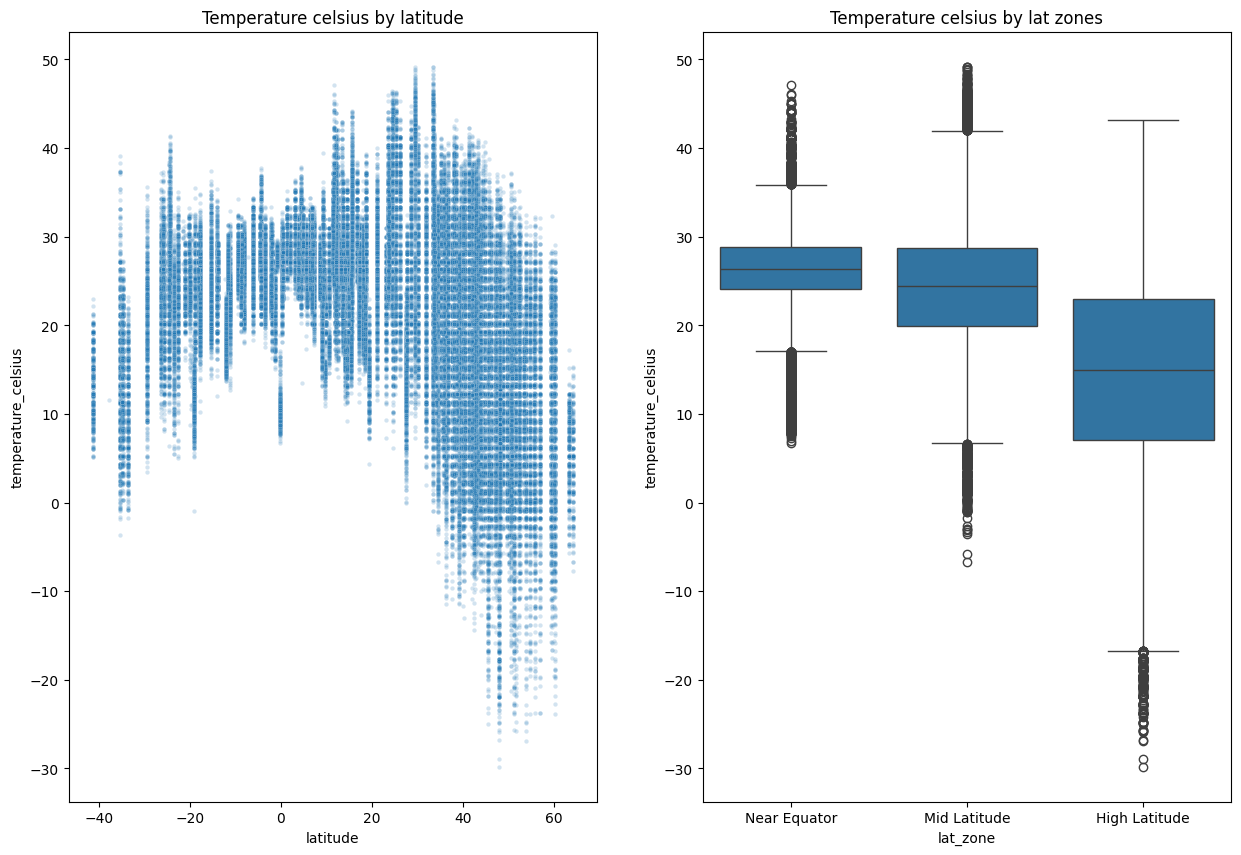

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,10))
axes = axes.flatten()
sns.scatterplot(x='latitude', y='temperature_celsius', data=weather_df,alpha=0.2,s=10, ax= axes[0])
axes[0].set_title('Temperature celsius by latitude')
sns.boxplot(
    x='lat_zone',
    y='temperature_celsius',
    data=weather_df,
    ax= axes[1]
)
axes[1].set_title('Temperature celsius by lat zones')

plt.show()



In [ ]:
weather_df.groupby('lat_zone')['temperature_celsius'].mean(), weather_df.groupby('lat_zone')['temperature_celsius'].median()

/tmp/ipython-input-353/565211417.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_df.groupby('lat_zone')['temperature_celsius'].mean(), weather_df.groupby('lat_zone')['temperature_celsius'].median()


(lat_zone
 Near Equator    26.119130
 Mid Latitude    24.294504
 High Latitude   14.864379
 Name: temperature_celsius, dtype: float64,
 lat_zone
 Near Equator    26.400000
 Mid Latitude    24.400000
 High Latitude   14.950000
 Name: temperature_celsius, dtype: float64)

Temperature clearly decreases as latitude increases. Near the equator, temperatures are the highest with a mean around 26.1°C and median 26.4°C, showing consistently warm conditions. Mid latitudes are slightly cooler with mean and median around 24.3–24.4°C, but still relatively warm overall. High latitudes drop significantly, with mean ~14.9°C, confirming much colder climates. The boxplot also shows more extreme low outliers in high latitudes (down to -30°C), while near-equator regions have tighter distributions, meaning temperatures there are more stable and less variable.

/tmp/ipython-input-353/656417771.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = weather_df.pivot_table(


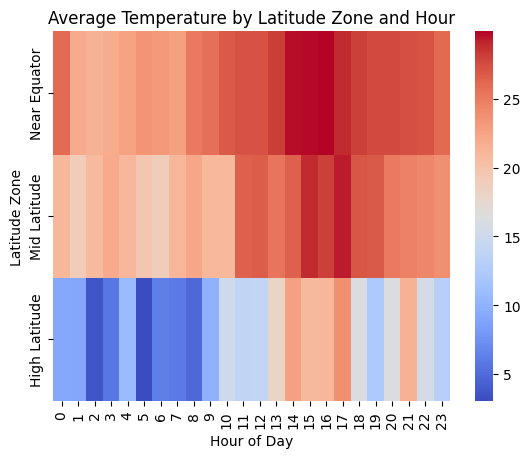

In [ ]:
pivot = weather_df.pivot_table(
    values='temperature_celsius',
    index='lat_zone',
    columns='Hour',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='coolwarm', cbar=True)
plt.title("Average Temperature by Latitude Zone and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Latitude Zone")
plt.show()


Temperature clearly depends on both the location and the time of day. Near the equator, temperatures stay high throughout the day with very little variation, showing a stable climate. In contrast, high latitude regions are much colder and show bigger changes, especially between night and afternoon. Across all zones, temperatures generally increase during the day, peak around mid to late afternoon, and then decrease again, which matches the normal daily weather cycle.

##Air quality and its correlation with various weather parameters

First, we will keep only numerical columns in order to display a correlation matrix.

In [ ]:
weather_df = weather_df.select_dtypes(include=['number'])

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)

In a new dataset, we will keep only the relevant columns to evaluate air quality with respect to various weather parameters, in order to avoid redundancy and noise

In [ ]:
relevant_cols = [
    'temperature_celsius',
    'humidity',
    'pressure_mb',
    'wind_kph',
    'uv_index',
    'visibility_km',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

weather_parameters = weather_df[relevant_cols]

All the columns that we excluded in the cell above were either irrelevant to weather parameters, or their values were already inferred by other columns in the dataset with different units of measure.

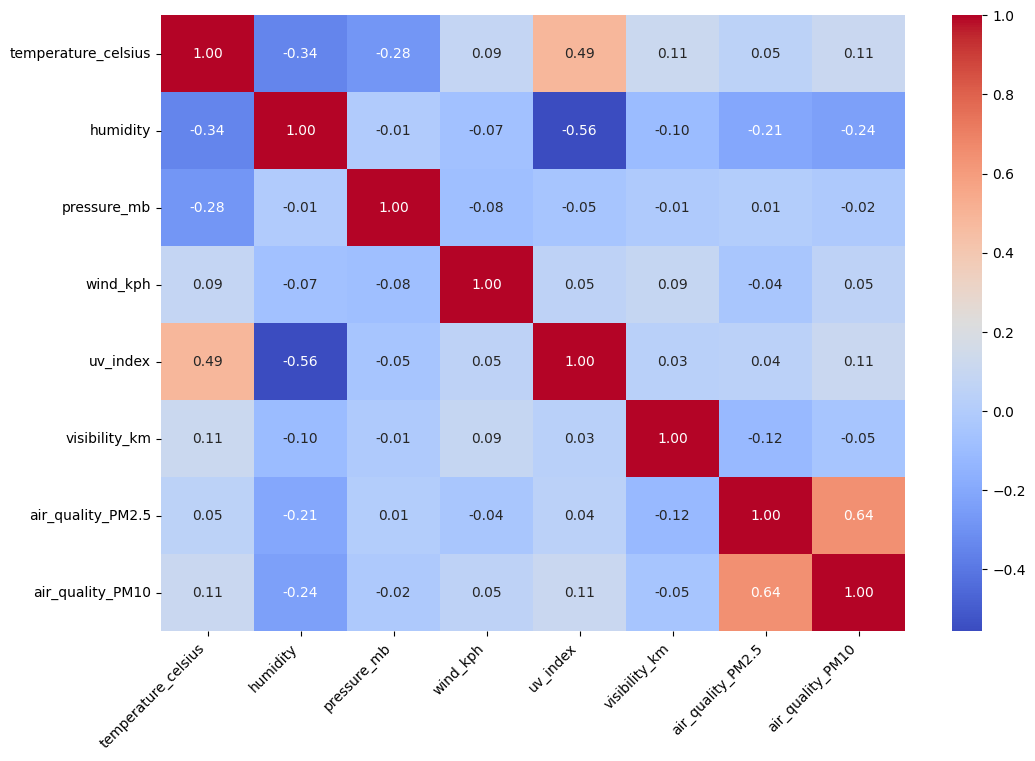

In [ ]:
corr = weather_parameters.corr()


plt.figure(figsize=(12,8))

sns.heatmap(weather_parameters.corr(),
            annot=True,
            fmt=".2f",
            cmap='coolwarm')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

Overall, we can see that most weather variables don’t have a very strong relationship with air quality, since the correlations are generally low. The only strong relationship is between PM2.5 and PM10 (0.64), which makes sense because they both measure similar types of particles in the air. Temperature has a moderate positive correlation with UV index (0.49), meaning hotter conditions usually come with higher UV levels, while humidity is strongly negatively correlated with UV (-0.56), showing that more humid conditions tend to reduce UV exposure. When it comes to air quality, humidity has a slight negative correlation with PM2.5 and PM10, suggesting that higher humidity may help reduce pollution slightly. Wind speed and pressure don’t seem to have much impact on air quality here, since their correlations are very close to zero.

(0.0, 150.0)

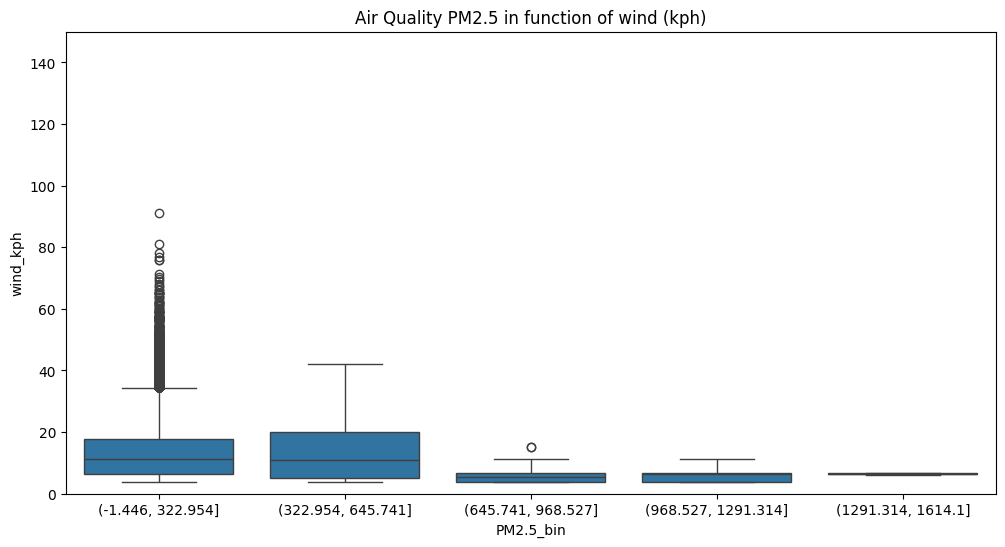

In [ ]:
fig, axes = plt.subplots(figsize=(12,6))

weather_df['PM2.5_bin'] = pd.cut(
    weather_df['air_quality_PM2.5'],
    bins=5
)

sns.boxplot(
    data=weather_df,
    x='PM2.5_bin',
    y='wind_kph'

)
axes.set_title('Air Quality PM2.5 in function of wind (kph)')
axes.set_ylim(0,150)


This boxplot shows that wind speed does not have a strong relationship with PM2.5 levels. Median wind speeds remain fairly similar across all pollution bins, indicating little overall change. However, lower PM2.5 levels show greater variability and more high outliers, suggesting occasional strong winds when air quality is better. As pollution increases, the spread of wind speeds narrows, though this may be due to fewer data points in higher ranges.

(0.0, 150.0)

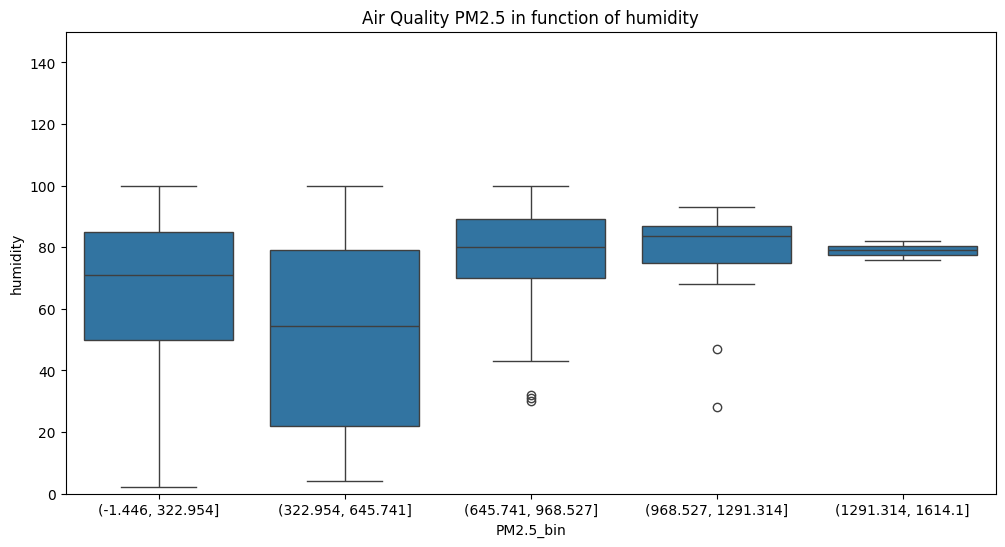

In [ ]:
fig, axes = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=weather_df,
    x='PM2.5_bin',
    y='humidity'

)
axes.set_title('Air Quality PM2.5 in function of humidity')
axes.set_ylim(0,150)

This boxplot doesn’t show a strong, consistent relationship between humidity and PM2.5. Most bins have fairly high median humidity (around the 70–85 range), so humidity alone doesn’t clearly separate “low” vs “high” pollution. What does change is variability: the lower PM2.5 bins have a much wider spread (humidity goes from very low to very high), while the highest PM2.5 bins are tighter and mostly clustered around high humidity. There are also a few low-humidity outliers even at higher PM2.5, which weakens any simple trend.

In conclusion, there aren't many clear correlations between air quality and weather parameters.

##**Forecasting with multiple models**

At this stage, we will start training ML models to forecast weather temperatures. We will be using Random Forest Regressor and Gradient Boosting for weather forecasting and Isolation Forest for anomaly detection.

First, let's have a look at our columns and select which ones to picks for model training. `temperature_celsius` will be our target variable

In [ ]:
weather_df.head().T

,186,52,40,68,124
country,United States of America,El Salvador,Costa Rica,Guatemala,Nicaragua
location_name,Washington Park,San Salvador,San Juan,Guatemala City,Managua
latitude,46.6,13.71,9.97,14.62,12.15
longitude,-120.49,-89.2,-84.08,-90.53,-86.27
timezone,America/Los_Angeles,America/El_Salvador,America/Costa_Rica,America/Guatemala,America/Managua
last_updated_epoch,1715849100,1715849100,1715849100,1715849100,1715849100
last_updated,2024-05-16 01:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00,2024-05-16 02:45:00
temperature_celsius,16.1,26.0,21.0,20.0,27.2
temperature_fahrenheit,61.0,78.8,69.8,68.0,80.9
wind_mph,4.3,2.2,2.2,13.6,3.6


In [ ]:
weather_df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'wind_mph', 'wind_kph', 'wind_degree',
       'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm',
       'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_illumination', 'Year', 'Month',
       'DayOfYear', 'Hour', 'Minute', 'Month_sin', 'Month_cos', 'Hour_sin',
       'Hour_cos', 'DayOfYear_sin', 'DayOfYear_cos', 'Minute_sin',
       'Minute_cos', 'lat_zone', 'daytime_duration_mins', 'wind_direction_sin'

We will store in a new dataframe only the columns that are relevant in weather forecasting and in numerical form.

In [ ]:
columns = ['latitude', 'wind_mph', 'wind_degree', 'pressure_mb', 'precip_mm', 'humidity',
           'cloud', 'visibility_km', 'uv_index', 'gust_mph', 'longitude', 'moon_illumination',
           'Year', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos','DayOfYear_sin', 'DayOfYear_cos',
           'daytime_duration_mins', 'wind_direction_sin', 'wind_direction_cos', 'temperature_celsius']

tmp_df = weather_df[columns]

Now, we can split our data into training and testing arrays. 80% of our data will be for trainig and 20% for testing. Since we want to

In [ ]:
split = int(len(tmp_df) * 0.8)

train_df = tmp_df[:split]
test_df = tmp_df[split:]

X_train = train_df.drop(columns=['temperature_celsius'])
y_train = train_df['temperature_celsius']

X_test = test_df.drop(columns=['temperature_celsius'])
y_test = test_df['temperature_celsius']


###Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

regressor = RandomForestRegressor(n_estimators=100, random_state = 42, oob_score= True)

regressor.fit(X_train, y_train)


RandomForestRegressor(oob_score=True, random_state=42)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error



y_preds_rf = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_preds_rf)
print(f'mean squared error : {mse}')
r2 = r2_score(y_test, y_preds_rf)
print(f'r-squared : {r2}')

mean squared error : 16.611377743996155
r-squared : 0.8608096063555002


In [ ]:
y = weather_df['temperature_celsius']

print(y.min(), y.max())
print(y.describe())

-29.8 49.2
count    124916.000000
mean         21.598439
std           9.593949
min         -29.800000
25%          16.300000
50%          24.100000
75%          28.100000
max          49.200000
Name: temperature_celsius, dtype: float64


The Random Forest model performs quite well overall. The R² score of around 0.86 means the model explains a large portion of the variation in temperature, so it’s capturing the main patterns in the data. The MSE (~16.6) is relatively low compared to the temperature range (about -30 to 49°C), which suggests the predictions are fairly close to the true values on average. Overall, the model is strong and reliable, and now we will evaluate which features are its most important :

In [ ]:
feature_importance = regressor.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': tmp_df.drop('temperature_celsius', axis=1).columns, 'Feature Importance' :
                feature_importance }).sort_values(
    'Feature Importance', ascending=False)
pd.set_option('display.float_format', '{:.6f}'.format)

In [ ]:
feature_imp_df

,Feature,Feature Importance
19,daytime_duration_mins,0.336903
0,latitude,0.177538
8,uv_index,0.158230
3,pressure_mb,0.108407
10,longitude,0.056920
5,humidity,0.043236
17,DayOfYear_sin,0.032095
18,DayOfYear_cos,0.021834
15,Hour_sin,0.012552
13,Month_sin,0.011689


This features importance dataframe results show that `daytime_duration_mins` is the most important feature, meaning the model mainly relies on seasonal daylight patterns to predict temperature. `latitude` and `uv_index` also have strong influence, which makes sense since they relate to sunlight and location. `pressure_mb` and `longitude` have moderate impact, while features like `humidity` and time encodings contribute less. Variables such as `wind_mph`, `precip_mm`, and `visibility_km` have very low importance, so they don’t affect temperature much in this model.

###Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(learning_rate=0.1,
                                n_estimators=300,
                                max_depth=1,
                                random_state=42,
                                max_features=5)

gbr.fit(X_train, y_train)
y_preds_gbr = gbr.predict(X_test)

mse = mean_squared_error(y_test, y_preds_gbr)
print(f'mean squared error : {mse}')
r2 = r2_score(y_test, y_preds_gbr)
print(f'r-squared : {r2}')

mean squared error : 26.98217938074762
r-squared : 0.7739103747279377


The gradient boosting results are slighly worse than the random forest regressor. We can try to fine tune the results (might take some time, maybe 4-5 minutes) :

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators': [200,300],
    'learning_rate': [0.05, 0.1,0.2],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.8, 0.9],
    'min_samples_split': [2, 5]
}
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(gbr,
                                   param_distributions=param_grid,
                                   n_iter=8,
                                   scoring='neg_mean_squared_error',
                                   cv=tscv,
                                   verbose=1,
                                   n_jobs=-1,
                                   random_state=42)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=GradientBoostingRegressor(max_depth=1,
                                                       max_features=5,
                                                       n_estimators=300,
                                                       random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'learning_rate': [0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [200, 300],
                                        'subsample': [0.8, 0.9]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=1)

In [ ]:
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 4, 'learning_rate': 0.1}


In [ ]:
best_params = random_search.best_params_
gbr_best = GradientBoostingRegressor(
    **best_params,
    random_state=42
)

gbr_best.fit(X_train, y_train)
y_preds = gbr_best.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
print(f'mean squared error : {mse}')
rmse = root_mean_squared_error(y_test, y_preds)
print(f'root mean squared error : {rmse}')
r2 = r2_score(y_test, y_preds)
print(f'r-squared : {r2}')

mean squared error : 12.526646411925018
root mean squared error : 3.539300271512014
r-squared : 0.8950364700633282


After tuning the Gradient Boosting model using RandomizedSearchCV, the performance improved significantly. The optimized model achieved a mean squared error of 12.52 and an RMSE of about 3.54°C, meaning predictions are now quite close to the actual temperatures on average. The R² score increased to 0.89, showing that the model explains a large portion of the variability in temperature. Overall, compared to the previous version, this tuned model captures the patterns in the data much better and provides more accurate and reliable predictions. This model also performs better than Random Forest Regressor that we initiallty trained (16.16 mse and 0.86 R^2) however it is worth noting that Random Forest achieved these results without having to fine tune its parameters in the first place.

In [ ]:
y_preds_ensemble = (y_preds_rf + y_preds_gbr) /2
print(f'mse for ensemble of models is {mean_squared_error(y_test, y_preds_ensemble)}')
print(f'R^2 for ensemble of models is {r2_score(y_test, y_preds_ensemble)}')

mse for ensemble of models is 17.9511368441083
R^2 for ensemble of models is 0.8495834697034208


The ensemble of models (random forest regressor and gradient boosting) predictions show solid results with 17.95 for mean squared error and 0.84 for r2 score.

###Features importance with Gradient Boosting

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    gbr_best,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_importance_df.head(10))

                  Feature  Importance
0                latitude    0.634047
19  daytime_duration_mins    0.196521
10              longitude    0.081481
3             pressure_mb    0.072319
5                humidity    0.050163
17          DayOfYear_sin    0.039491
8                uv_index    0.012668
13              Month_sin    0.003469
6                   cloud    0.003008
21     wind_direction_cos    0.002342


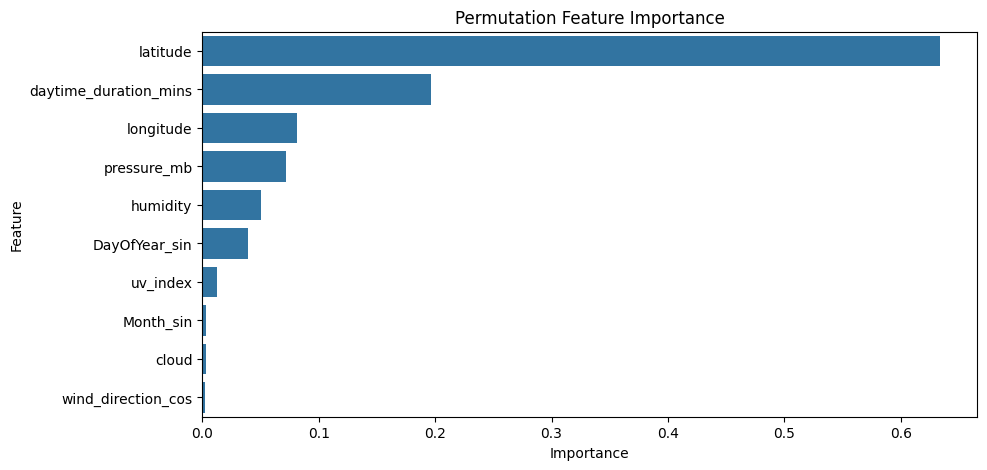

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=perm_importance_df.head(10), x='Importance', y='Feature')
plt.title("Permutation Feature Importance")
plt.show()

Permutation importance highlights latitude as the dominant feature by a large margin, indicating that geographical location plays a major role in determining temperature. Daytime duration also remains highly influential, reinforcing the importance of seasonal and sunlight-related patterns. Other features such as longitude, pressure, and humidity contribute moderately, while variables like cloud and wind direction have minimal impact. Overall, the results confirm that both spatial location and time-related factors are key drivers of temperature variation.

###Isolation Forest - Anomaly Detection

Now we will perform anomaly detection using Isolation Forest. We will be detecting values that seem anomalous or significantly different from the general distribution of the data.

In [ ]:
from sklearn.ensemble import IsolationForest

iso_fo = IsolationForest(contamination=0.1)

iso_fo.fit(X_train)
train_preds = iso_fo.predict(X_train)
test_preds = iso_fo.predict(X_test)
X_test_copy = X_test.copy()

X_test_copy['anomaly'] = test_preds

print((test_preds == -1).sum(), "anomalies detected")
print((test_preds == 1).sum(), "normal points")


5166 anomalies detected
19818 normal points


In [ ]:

scores = iso_fo.decision_function(X_test)

X_test_copy['anomaly_score'] = scores
X_test_copy.sort_values(by='anomaly_score').head(10)

,latitude,wind_mph,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,gust_mph,...,Month_cos,Hour_sin,Hour_cos,DayOfYear_sin,DayOfYear_cos,daytime_duration_mins,wind_direction_sin,wind_direction_cos,anomaly,anomaly_score
124259,-41.3000,41.6,206,1003.0,3.93,88,100,1.1,0.1,50.2,...,0.500000,-0.965926,0.258819,0.711657,0.702527,821,-3.826834e-01,-9.238795e-01,-1,-0.123138
110036,-41.3000,26.4,168,998.0,2.29,88,100,10.0,0.0,35.9,...,1.000000,-0.866025,0.500000,-0.463550,0.886071,897,3.826834e-01,-9.238795e-01,-1,-0.116506
102821,-41.3000,37.1,328,985.0,0.63,88,75,5.0,0.0,54.8,...,0.500000,-0.707107,0.707107,-0.899631,0.436651,822,-3.826834e-01,9.238795e-01,-1,-0.102285
121393,-8.5167,23.3,313,1008.0,9.05,93,100,5.0,0.0,34.9,...,0.866025,-0.965926,0.258819,0.508671,0.860961,749,-7.071068e-01,7.071068e-01,-1,-0.099724
111744,64.1500,28.9,104,972.0,1.60,87,100,10.0,0.0,37.7,...,1.000000,0.965926,-0.258819,-0.321270,0.946988,259,9.238795e-01,-3.826834e-01,-1,-0.099128
114084,64.1500,31.1,176,1012.0,1.11,93,100,6.0,0.0,45.9,...,1.000000,0.965926,-0.258819,-0.120208,0.992749,248,1.224647e-16,-1.000000e+00,-1,-0.096792
121919,-41.3000,27.1,174,1008.0,0.80,94,100,4.1,0.0,34.6,...,0.500000,-0.866025,0.500000,0.552435,0.833556,851,1.224647e-16,-1.000000e+00,-1,-0.096634
112719,64.1500,38.0,83,967.0,1.17,65,75,10.0,0.0,49.6,...,1.000000,0.965926,-0.258819,-0.238673,0.971100,249,1.000000e+00,6.123234e-17,-1,-0.095111
120513,53.3331,26.8,131,968.0,4.00,100,75,4.0,0.0,34.9,...,0.866025,0.965926,-0.258819,0.448229,0.893919,522,7.071068e-01,-7.071068e-01,-1,-0.094739
108866,-41.3000,25.1,337,1002.0,0.10,94,100,1.4,0.1,40.6,...,0.866025,-0.866025,0.500000,-0.552435,0.833556,889,-3.826834e-01,9.238795e-01,-1,-0.093811


Our Isolation Forest model detected 5,166 anomalies our dataset, with the highest one having an anomaly_score of -0.123138. These rows' data points deviate from the normal patterns in the dataset.